# Partition-Optimal Pareto Frontiers vs. Peak FLOPS

**Question:** how does the (throughput/GPU, interactivity) Pareto frontier shift as device peak FLOPS grows, and which (PP, TP, EP, SP) partition wins at each frontier corner?

**Method:** for each peak-FLOPS setting, sweep all valid (PP, TP, EP, SP) partitions × batch sizes B, keep the upper-right envelope in (tput/GPU, 1/TPOT) space, and record the winning partition at each frontier point. HBM bandwidth and scale-up I/O are held fixed — only the compute roofline ceiling varies.

**Structure:**

- §1–7: main sweep at $S$=8192.
- §8: roofline diagnostic explaining why the curves collapse.
- §9: companion sweep at $S$=1024 — the regime where FLOPS *does* help.
- §10: takeaway + link to the full explainer.

Model, system, and tuner are configured in Section 1 — swap the database paths there to study a different setup.

## 1. Imports and spec loading

In [1]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec

# Configuration — matches the NVIDIA inference blog (GPT-1.8T MoE @ FP4,
# GB200 NVL72). Swap these paths to study a different model/system.
MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.72gpu.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5  # GB200 inference precision.

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

base_hbm = system.device.hbm_bandwidth_GBps
base_up_bw = system.network_domains["TP"].bandwidth_GBps
base_up_alpha = system.network_domains["TP"].alpha_us
base_peak_tf = system.device.peak_flops_TF
print(f"Model: {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  bytes/param={model.bytes_per_param}")
print(f"System: {system.num_devices} GPUs  HBM={base_hbm:.0f} GB/s  peak={base_peak_tf:.0f} TF  scale-up={base_up_bw:.0f} GB/s · {base_up_alpha:.2f} μs")

Model: GPT-1.8T-MoE  L=120  H=20480  n_kv=16  bytes/param=0.5
System: 72 GPUs  HBM=8000 GB/s  peak=9000 TF  scale-up=900 GB/s · 0.50 μs


## 2. Partition enumeration

GPT-1.8T MoE imposes divisibility constraints: `PP | L=120`, `TP | n_kv=16` and `H=20480`, `EP | n_experts=16`. We keep `SP=1`. Candidates exceeding 72 GPUs are dropped.

In [2]:
PP_CHOICES = [1, 2, 3, 4, 6, 8]
TP_CHOICES = [1, 2, 4, 8, 16]
EP_CHOICES = [1, 2, 4, 8, 16]
SP_CHOICES = [1]


def enumerate_partitions(num_devices: int) -> list[PartitionSpec]:
    out: list[PartitionSpec] = []
    for pp in PP_CHOICES:
        for tp in TP_CHOICES:
            for ep in EP_CHOICES:
                for sp in SP_CHOICES:
                    if pp * tp * ep * sp > num_devices:
                        continue
                    out.append(PartitionSpec(PP=pp, TP=tp, EP=ep, SP=sp))
    return out


partitions = enumerate_partitions(system.num_devices)
print(f"Valid partitions: {len(partitions)}")

Valid partitions: 91


## 3. Partition sweep + Pareto frontier helpers

For each partition we derive `B_max` from the KV paging model and sweep log-spaced batch sizes. Each evaluation produces a point in (tput/GPU, 1/TPOT) space. We then walk the points in order of decreasing tput/GPU and keep those that strictly improve interactivity — the upper-right envelope.

In [3]:
@dataclass
class Point:
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"


def log_spaced_batch_sizes(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def sweep_partition(model, system, partition, tuner_base) -> list[Point]:
    try:
        mem = compute_memory(model, system, partition, tuner_base)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model, system, partition, tuner_base, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []

    pts: list[Point] = []
    for B in log_spaced_batch_sizes(b_max):
        tuner = deepcopy(tuner_base)
        tuner.B_decode = B
        try:
            r = InferenceCalculator(model, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(Point(
            partition=partition,
            B=B,
            tput_per_gpu=r.latency.TTPS / system.num_devices,
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
        ))
    return pts


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best_interact = -math.inf
    for p in sorted_pts:
        if p.interactivity > best_interact + 1e-9:
            frontier.append(p)
            best_interact = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier

## 4. Peak FLOPS scaling helper

Only the device's peak FLOPS is scaled. HBM bandwidth and scale-up I/O (TP/EP/SP/PP collectives) are held fixed so we isolate the compute-roofline effect.

In [4]:
def scale_system_peak_flops(base_system, flops_mult: float):
    s = deepcopy(base_system)
    s.device.peak_flops_TF *= flops_mult
    return s


def frontier_for_flops(model, base_system, partitions, tuner_base,
                       flops_mult: float) -> list[Point]:
    sys_m = scale_system_peak_flops(base_system, flops_mult)
    all_pts: list[Point] = []
    for part in partitions:
        all_pts.extend(sweep_partition(model, sys_m, part, tuner_base))
    return pareto_frontier(all_pts)

## 5. Run the sweeps

Improvement-only sweep: peak FLOPS stays ≥ 1× base. Anchors (base = 9 PF FP4 dense, per GB200):

- `0.5×` — roughly H100-class SM compute budget projected onto FP4 (~4.5 PF).
- `1.0×` — baseline GB200 (9 PF).
- `2.0×` — next-gen GPU class (~18 PF).
- `4.0×` — aggressive future / scaled-up die (~36 PF).

**Ideal compute reference** — peak FLOPS → ∞: the memory + scale-up ceiling.

In [5]:
FLOPS_MULTIPLIERS = [0.5, 1.0, 2.0, 4.0]

flops_frontiers: dict[str, list[Point]] = {}
for mult in FLOPS_MULTIPLIERS:
    abs_tf = mult * base_peak_tf
    label = f"FLOPS={abs_tf/1000:.1f} PF  ({mult:g}× base)"
    print(f"[FLOPS] {label} ...")
    flops_frontiers[label] = frontier_for_flops(model, system, partitions, tuner_base, mult)

print("[ideal compute] peak FLOPS → ∞ ...")
ideal_compute_frontier = frontier_for_flops(model, system, partitions, tuner_base, flops_mult=1e6)

print(f"\nFrontiers computed: {len(flops_frontiers)} FLOPS × 1 ideal")

[FLOPS] FLOPS=4.5 PF  (0.5× base) ...
[FLOPS] FLOPS=9.0 PF  (1× base) ...
[FLOPS] FLOPS=18.0 PF  (2× base) ...
[FLOPS] FLOPS=36.0 PF  (4× base) ...
[ideal compute] peak FLOPS → ∞ ...

Frontiers computed: 4 FLOPS × 1 ideal


## 6. Winners summary

For each frontier we count how many of its points are won by each (PP, TP, EP, SP) partition. A single-partition frontier means that shape is robust across batch corners; diversity means different partitions win at different corners.

In [6]:
def winners(frontier: list[Point]) -> list[tuple[str, int]]:
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    return sorted(counts.items(), key=lambda kv: -kv[1])


def print_winners(title: str, frontiers: dict[str, list[Point]]):
    print(f"── {title} " + "─" * max(0, 64 - len(title)))
    for label, fr in frontiers.items():
        w = winners(fr)
        top = ", ".join(f"{k} ({v})" for k, v in w)
        print(f"  {label}")
        print(f"    winners: {top}")


print_winners("Peak FLOPS sweep", flops_frontiers)
print()
print("── Ideal compute (peak FLOPS → ∞) " + "─" * 36)
for k, v in winners(ideal_compute_frontier):
    print(f"  {k}: {v}")

── Peak FLOPS sweep ────────────────────────────────────────────────
  FLOPS=4.5 PF  (0.5× base)
    winners: PP=8 TP=8 EP=1 SP=1 (34), PP=6 TP=4 EP=1 SP=1 (4)
  FLOPS=9.0 PF  (1× base)
    winners: PP=8 TP=8 EP=1 SP=1 (34), PP=6 TP=4 EP=1 SP=1 (4)
  FLOPS=18.0 PF  (2× base)
    winners: PP=8 TP=8 EP=1 SP=1 (34), PP=6 TP=4 EP=1 SP=1 (4)
  FLOPS=36.0 PF  (4× base)
    winners: PP=8 TP=8 EP=1 SP=1 (34), PP=6 TP=4 EP=1 SP=1 (4)

── Ideal compute (peak FLOPS → ∞) ────────────────────────────────────
  PP=8 TP=8 EP=1 SP=1: 34
  PP=6 TP=4 EP=1 SP=1: 4


## 7. Pareto plot

X = interactivity (1/TPOT), Y = throughput/GPU — matches the NVIDIA inference-blog convention.

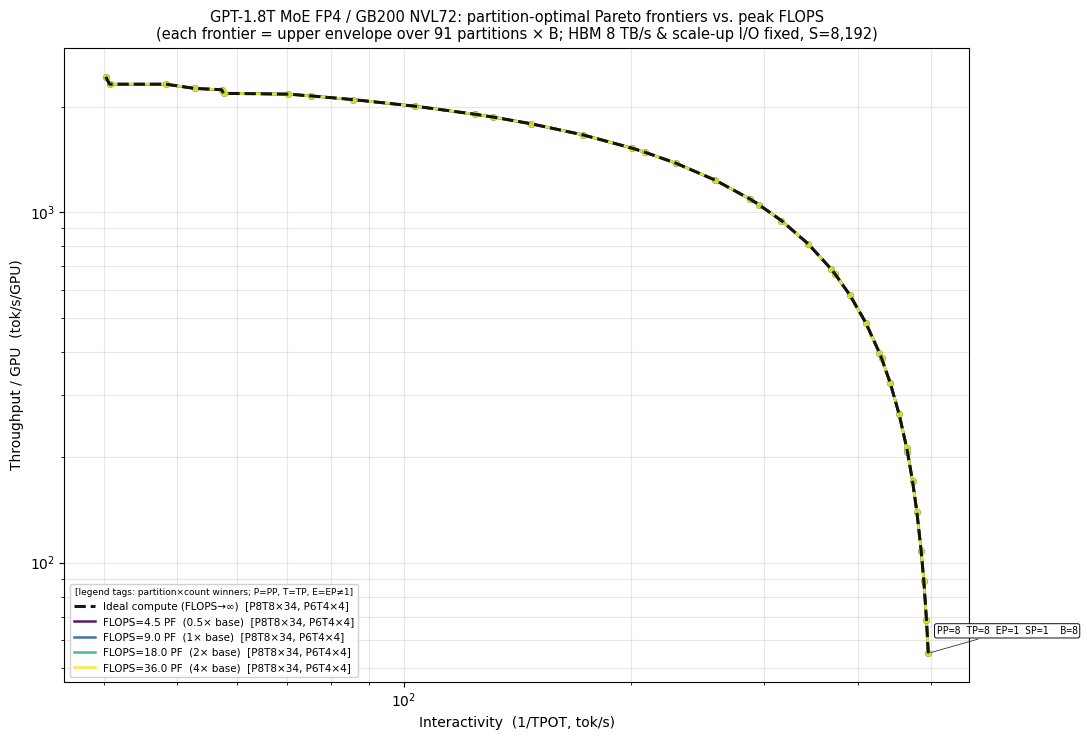

In [7]:
def winners_tag(frontier: list[Point]) -> str:
    """Compact label for legend: P=PP T=TP E=EP (drops EP=1 SP=1)."""
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    def short(name: str) -> str:
        return (name.replace(" EP=1", "").replace(" SP=1", "")
                    .replace("PP=", "P").replace("TP=", "T")
                    .replace("EP=", "E").replace(" ", ""))
    items = sorted(counts.items(), key=lambda kv: -kv[1])
    return ", ".join(f"{short(k)}×{v}" for k, v in items)


def annotate_ideal(ax, frontier, color="black"):
    if not frontier:
        return
    seen: set[str] = set()
    picks: list[int] = []
    for i, p in enumerate(frontier):
        if p.part_label not in seen:
            seen.add(p.part_label); picks.append(i)
    min_log_dx = 0.30
    last_logx = -math.inf
    kept: list[int] = []
    for idx in picks:
        lx = math.log10(max(1e-9, frontier[idx].interactivity))
        if lx - last_logx >= min_log_dx:
            kept.append(idx); last_logx = lx
    offsets = [(6, 14), (6, -20), (6, 32), (6, -38)]
    for j, idx in enumerate(kept):
        p = frontier[idx]
        dx, dy = offsets[j % len(offsets)]
        ax.annotate(
            f"{p.part_label}  B={p.B}",
            xy=(p.interactivity, p.tput_per_gpu),
            xytext=(dx, dy), textcoords="offset points",
            fontsize=7, family="monospace", color="black", ha="left",
            bbox=dict(boxstyle="round,pad=0.22", fc="white",
                      ec=color, alpha=0.95, lw=0.7),
            arrowprops=dict(arrowstyle="-", color=color, lw=0.6, alpha=0.8),
        )


fig, ax = plt.subplots(figsize=(11, 7.5))
cmap = plt.get_cmap("viridis")
labels = list(flops_frontiers.keys())
colors = [cmap(i / max(1, len(labels) - 1)) for i in range(len(labels))]

if ideal_compute_frontier:
    ax.plot([p.interactivity for p in ideal_compute_frontier],
            [p.tput_per_gpu for p in ideal_compute_frontier],
            "--", lw=2.2, color="black", alpha=0.9,
            label=f"Ideal compute (FLOPS→∞)  [{winners_tag(ideal_compute_frontier)}]", zorder=6)

for (label, fr), color in zip(flops_frontiers.items(), colors):
    if not fr:
        continue
    ax.plot([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
            "-", lw=1.8, color=color, alpha=0.9,
            label=f"{label}  [{winners_tag(fr)}]")
    ax.scatter([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
               s=14, color=color, alpha=0.75, zorder=3)

if ideal_compute_frontier:
    annotate_ideal(ax, ideal_compute_frontier, "black")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Interactivity  (1/TPOT, tok/s)")
ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
ax.set_title(
    f"GPT-1.8T MoE FP4 / GB200 NVL72: partition-optimal Pareto frontiers vs. peak FLOPS\n"
    f"(each frontier = upper envelope over {len(partitions)} partitions × B; "
    f"HBM {base_hbm/1000:.0f} TB/s & scale-up I/O fixed, S={S_DECODE:,})",
    fontsize=10.5,
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(
    loc="lower left", fontsize=7.5, framealpha=0.9,
    title="[legend tags: partition×count winners; P=PP, T=TP, E=EP≠1]",
    title_fontsize=6.5,
)
fig.tight_layout()
fig.savefig("assets/pareto_vs_flops.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Roofline diagnostic — why the $S$=8192 curves overlap

If $t_{mem} \gg t_{compute}$ at every $B$ on the frontier, then $t_{token} = \max(t_{compute}, t_{mem}) \approx t_{mem}$ and extra FLOPS disappears into the `max`. Below we read the two terms off the winning partition (PP=8, TP=8) at 1× and 4× FLOPS to confirm the decode path is memory-bound across the whole valid $B$ range.

**Slope read-out.** At 1× FLOPS the slopes with $B$ are $t_{compute}$ ~ 1.27 μs/B and $t_{mem}$ ~ 4.9 μs/B. The memory slope is ~4× larger, so the two lines **diverge** as $B$ grows — no finite crossover exists. In $B^*$ terms: $F_{token}\cdot B_{eff,mem} - T_{kv}\cdot R_{gpu} < 0$. See `documentation/explaining/why_flops_doesnt_help_at_long_context.md` for the full derivation.

In [8]:
from llm_perf.specs.partition_spec import PartitionSpec

winner = PartitionSpec(PP=8, TP=8, EP=1, SP=1)
B_list = [1, 8, 32, 128, 256, 512]

print(f"Winning partition: PP={winner.PP} TP={winner.TP} EP={winner.EP} SP={winner.SP}")
print(f"{'mult':>6} {'B':>6} {'t_compute_us':>14} {'t_mem_us':>10} {'t_mem/t_comp':>14} {'bound':>10}")
for mult in [1.0, 4.0]:
    sys_m = scale_system_peak_flops(system, mult)
    for B in B_list:
        t = deepcopy(tuner_base); t.B_decode = B
        try:
            r = InferenceCalculator(model, sys_m, winner, t).run()
        except Exception as e:
            continue
        tc, tm = r.latency.t_compute * 1e6, r.latency.t_mem * 1e6
        bound = "compute" if tc > tm else "memory"
        print(f"{mult:>6g} {B:>6} {tc:>14.2f} {tm:>10.2f} {tm/max(tc,1e-9):>14.2f} {bound:>10}")

Winning partition: PP=8 TP=8 EP=1 SP=1
  mult      B   t_compute_us   t_mem_us   t_mem/t_comp      bound
     1      1           1.27    1767.01        1393.41     memory
     1      8          10.14    1801.42         177.57     memory
     1     32          40.58    1919.39          47.30     memory
     1    128         162.32    2391.24          14.73     memory
     1    256         324.64    3020.39           9.30     memory
     1    512         649.28    4278.68           6.59     memory
     4      1           0.32    1767.01        5573.64     memory
     4      8           2.54    1801.42         710.27     memory
     4     32          10.14    1919.39         189.20     memory
     4    128          40.58    2391.24          58.93     memory
     4    256          81.16    3020.39          37.22     memory
     4    512         162.32    4278.68          26.36     memory


## 9. Short-context companion sweep (S=1024)

The slope analysis in §8 predicts that FLOPS becomes a live knob when $T_{kv}$'s slope in $B$ drops enough to let $t_{compute}$ overtake $t_{mem}$. The fastest way to shrink $T_{kv}$ is to shrink $S$ — KV traffic per decode step scales linearly with context length. Below we rerun the same FLOPS sweep at $S$=1024 and plot both context lengths side-by-side.

**Prediction:** at $S$=1024 the per-$B$ AI should rise enough that, past some finite $B^*$, the step flips compute-bound — and then more FLOPS lifts the high-throughput corner of the frontier. At $S$=8192 the curves remain collapsed (as in §7).

In [9]:
S_SHORT = 1024
tuner_short = deepcopy(tuner_base)
tuner_short.S_decode = S_SHORT

flops_frontiers_short: dict[str, list[Point]] = {}
for mult in FLOPS_MULTIPLIERS:
    abs_tf = mult * base_peak_tf
    label = f"FLOPS={abs_tf/1000:.1f} PF  ({mult:g}× base)"
    print(f"[FLOPS S={S_SHORT}] {label} ...")
    flops_frontiers_short[label] = frontier_for_flops(
        model, system, partitions, tuner_short, mult)

print(f"[ideal compute S={S_SHORT}] peak FLOPS → ∞ ...")
ideal_compute_frontier_short = frontier_for_flops(
    model, system, partitions, tuner_short, flops_mult=1e6)

# Diagnostic on the dominant winner at S=1024 to show the slope flip
print()
print(f"── Roofline diagnostic at S={S_SHORT}  (PP=8 TP=8 EP=1 SP=1)  " + "─" * 10)
print(f"{'mult':>6} {'B':>6} {'t_compute_us':>14} {'t_mem_us':>10} {'bound':>10}  {'tput/GPU':>10}")
winner = PartitionSpec(PP=8, TP=8, EP=1, SP=1)
for mult in [1.0, 4.0]:
    sys_m = scale_system_peak_flops(system, mult)
    for B in [1, 64, 512, 2048, 8192]:
        t = deepcopy(tuner_short); t.B_decode = B
        try:
            r = InferenceCalculator(model, sys_m, winner, t).run()
        except Exception:
            continue
        tc, tm = r.latency.t_compute * 1e6, r.latency.t_mem * 1e6
        bound = "compute" if tc > tm else "memory"
        print(f"{mult:>6g} {B:>6} {tc:>14.2f} {tm:>10.2f} {bound:>10}  {r.latency.TTPS/sys_m.num_devices:>10.1f}")

[FLOPS S=1024] FLOPS=4.5 PF  (0.5× base) ...
[FLOPS S=1024] FLOPS=9.0 PF  (1× base) ...
[FLOPS S=1024] FLOPS=18.0 PF  (2× base) ...
[FLOPS S=1024] FLOPS=36.0 PF  (4× base) ...
[ideal compute S=1024] peak FLOPS → ∞ ...

── Roofline diagnostic at S=1024  (PP=8 TP=8 EP=1 SP=1)  ──────────
  mult      B   t_compute_us   t_mem_us      bound    tput/GPU
     1      1           1.15    1762.71     memory         0.9
     1     64          73.33    1801.42     memory       433.6
     1    512         586.64    2076.67     memory      2741.6
     1   2048        2346.57    3020.39     memory      6381.8
     1   8192        9386.29    6795.26    compute      7845.8
     4      1           0.29    1762.71     memory         0.9
     4     64          18.33    1801.42     memory       433.6
     4    512         146.66    2076.67     memory      2741.6
     4   2048         586.64    3020.39     memory      6381.8
     4   8192        2346.57    6795.26     memory      9552.5


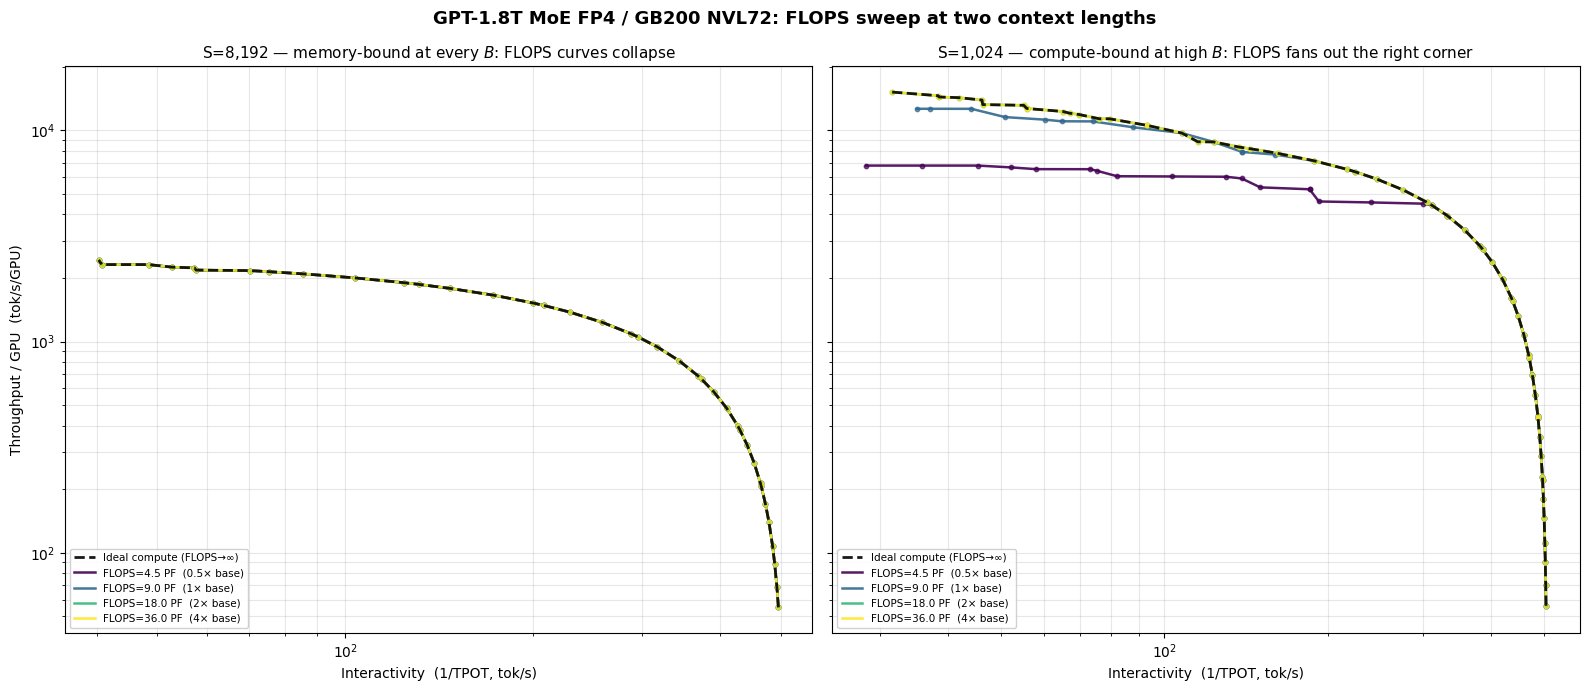

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
cmap = plt.get_cmap("viridis")
labels_long  = list(flops_frontiers.keys())
labels_short = list(flops_frontiers_short.keys())
colors = [cmap(i / max(1, len(labels_long) - 1)) for i in range(len(labels_long))]

def draw_panel(ax, frontiers, ideal, title):
    if ideal:
        ax.plot([p.interactivity for p in ideal],
                [p.tput_per_gpu for p in ideal],
                "--", lw=2.0, color="black", alpha=0.9,
                label=f"Ideal compute (FLOPS→∞)", zorder=6)
    for (label, fr), color in zip(frontiers.items(), colors):
        if not fr:
            continue
        ax.plot([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
                "-", lw=1.8, color=color, alpha=0.9, label=label)
        ax.scatter([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
                   s=10, color=color, alpha=0.7, zorder=3)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Interactivity  (1/TPOT, tok/s)")
    ax.set_title(title, fontsize=11)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="lower left", fontsize=7.5, framealpha=0.9)

draw_panel(axes[0], flops_frontiers,       ideal_compute_frontier,
           f"S={S_DECODE:,} — memory-bound at every $B$: FLOPS curves collapse")
draw_panel(axes[1], flops_frontiers_short, ideal_compute_frontier_short,
           f"S={S_SHORT:,} — compute-bound at high $B$: FLOPS fans out the right corner")

axes[0].set_ylabel("Throughput / GPU  (tok/s/GPU)")
fig.suptitle(
    f"GPT-1.8T MoE FP4 / GB200 NVL72: FLOPS sweep at two context lengths",
    fontsize=13, fontweight="bold",
)
fig.tight_layout()
fig.savefig("assets/pareto_vs_flops_short_vs_long.png", dpi=130, bbox_inches="tight")
plt.show()

## 10. What to take away

- **At $S$=8192, peak FLOPS is a non-knob.** All four sweep curves (0.5× → 4×) and even the ideal-compute reference (FLOPS → ∞) overlap exactly. The §8 diagnostic shows the cause: $t_{compute}$'s slope in $B$ (~1.27 μs/B) is *smaller* than $t_{mem}$'s slope (~4.9 μs/B), so the two lines diverge as $B$ grows. The $B^*$ denominator $F_{token}\cdot B_{eff,mem} - T_{kv}\cdot R_{gpu}$ is negative — no finite crossover exists.
- **At $S$=1024, FLOPS re-enters the picture.** The per-$B$ $T_{kv}$ slope drops ~8× (KV traffic is linear in $S$). At $B$=8192 on PP=8 TP=8 with 1× FLOPS, $t_{compute}$=9.4 ms > $t_{mem}$=6.8 ms — the step has flipped **compute-bound**. Throughput/GPU at the high-$B$ corner then lifts from ~7850 → ~9550 tok/s/GPU when FLOPS is scaled 1× → 4×. The short-context panel fans out on the right side exactly as textbook roofline predicts.
- **Mirror of `pareto_vs_mem`.** At long $S$, HBM BW moves both frontier corners because this workload is memory-bound end-to-end; peak FLOPS moves neither. At short $S$, the corners split: memory bandwidth still drives the low-$B$ / high-interactivity corner, and FLOPS now drives the high-$B$ / high-throughput corner.
- **Practical implication.** For chat/agent workloads pinned to long context on a small-ish scale-up domain, FLOPS is the wrong knob to buy — invest in HBM bandwidth, KV compression (MLA / smaller $n_{kv}$), or larger $TP$ on the KV path. FLOPS only matters when the per-$B$ arithmetic intensity $F_{token}/T_{kv}$ exceeds the machine's $R_{gpu}/B_{eff,mem}$ balance — and that condition depends on $S$, KV architecture, and cluster size as much as on the GPU spec.
- **When FLOPS is always the right knob: prefill and training.** Those workloads process many tokens at once (per step), which changes the compute/memory ratio fundamentally — see `documentation/explaining/why_flops_doesnt_help_at_long_context.md` §7.

See `documentation/explaining/why_flops_doesnt_help_at_long_context.md` for the full AI / slope derivation and `documentation/explaining/frontier_convergence_at_high_b.md` for the $B^*$ story in general.